In [8]:
%pip install -U langgraph langchain python-dotenv langchain-openrouter


  Obtaining dependency information for langchain-openrouter from https://files.pythonhosted.org/packages/56/9d/f8c8ac721dff192a4378b645c6000a9eda828e0af0f91922b1c024bbe927/langchain_openrouter-0.2.8-py3-none-any.whl.metadata
  Using cached langchain_openrouter-0.2.8-py3-none-any.whl.metadata (3.4 kB)
  Obtaining dependency information for openrouter<1.0.0,>=0.9.2 from https://files.pythonhosted.org/packages/08/e3/0504f94e182c8975750bc9eb280552cf9cec9a7ffe20edeb44a825fa605d/openrouter-0.11.46-py3-none-any.whl.metadata
  Using cached openrouter-0.11.46-py3-none-any.whl.metadata (9.4 kB)
  Obtaining dependency information for jsonpath-python>=1.0.6 from https://files.pythonhosted.org/packages/55/8a/1270a6803bd821cbfcdda387eaa13cb41a7b1f7b9bd145979b3bfb9d6cb7/jsonpath_python-1.1.6-py3-none-any.whl.metadata
  Using cached jsonpath_python-1.1.6-py3-none-any.whl.metadata (17 kB)
  Obtaining dependency information for pydantic>=2.7.4 from https://files.pythonhosted.org/packages/5a/87/b70ad306e


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from langgraph.graph import StateGraph, START, END
from langchain_openrouter import ChatOpenRouter
from typing import TypedDict
from dotenv import load_dotenv
import os

In [11]:
load_dotenv()  # Load environment variables from .env file

True

In [14]:
model = ChatOpenRouter(model_name="nvidia/nemotron-3.5-lightning:free", api_key=os.getenv("OPEN_AI_ROUTER"))

In [16]:
class QAState(TypedDict):
    question: str
    answer: str

In [18]:
def llm_qa(state: QAState) -> QAState:

    # extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'Answer the following question {question}'

    # ask that question to the LLM
    answer = model.invoke(prompt).content

    # update the answer in the state
    state['answer'] = answer

    return state

In [25]:
graph = StateGraph(QAState)

# add nodes
graph.add_node('llm_qa', llm_qa)

# add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

# compile
workflow = graph.compile()

In [26]:
# execute

intial_state = {'question': 'Who is the creator of Python?'}

final_state = workflow.invoke(intial_state)

print(final_state['answer'])

The creator of Python is **Guido van Rossum**. He began working on the language in the late 1980s and released the first version in 1991. He's also well known for serving as the project's "Benevolent Dictator For Life" (BDFL) until he stepped down from that role in 2018.


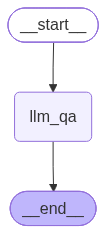

In [27]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())